In [1]:
import pandas as pd

In [2]:
nav_history=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\nav_history_cleaned.csv")

In [3]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
scheme_performance=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\scheme_performance_cleaned.csv")

In [5]:
nav_scheme=pd.merge(nav_history,scheme_performance,on='amfi_code',how='left')
nav_scheme.head()

,amfi_code,date,nav,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,...,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate


In [6]:
import plotly.express as px

In [7]:
nav_scheme.dtypes

amfi_code               int64
date                      str
nav                   float64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object

In [8]:
nav_scheme['date']=pd.to_datetime(nav_scheme['date'])

### NAV trend analysis

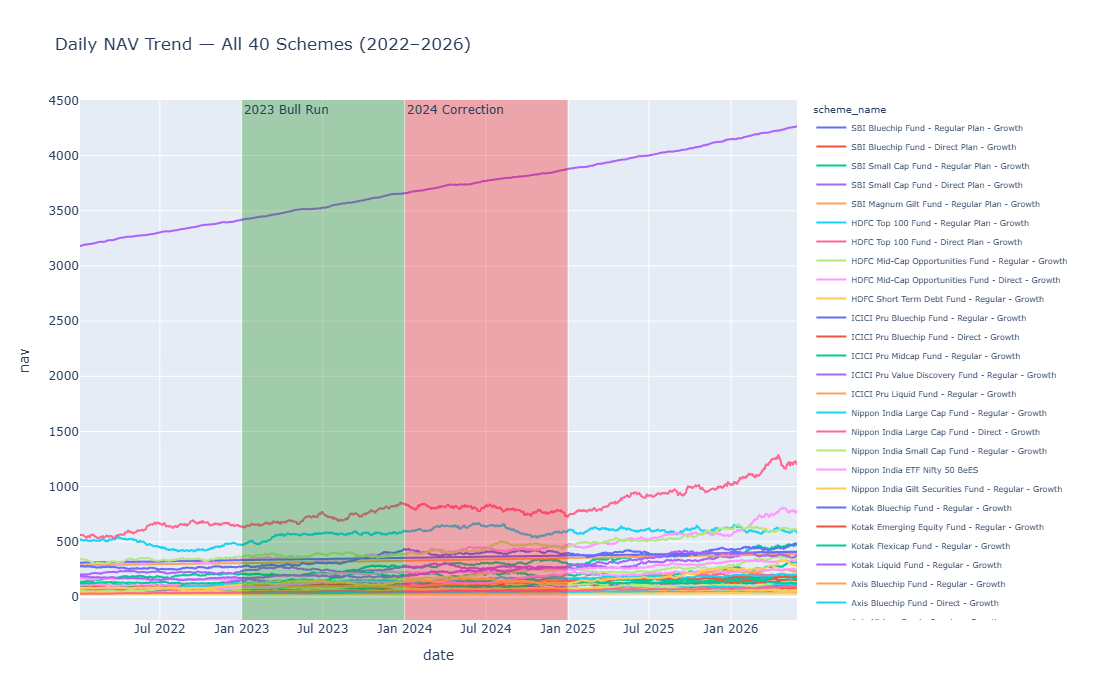

In [38]:
# Build the line chart: one line per scheme_name, x=date, y=nav
fig = px.line(
    nav_scheme,
    x='date',
    y='nav',
    color='scheme_name',  
    title='Daily NAV Trend — All 40 Schemes (2022–2026)'
)
# Highlight the 2023 bull run — shaded green band
fig.add_vrect(
    x0='2023-01-01', x1='2023-12-31',
    fillcolor='green', opacity=0.3, line_width=0,
    annotation_text='2023 Bull Run', annotation_position='top left'
)
# Highlight the 2024 correction — shaded red band
fig.add_vrect(
    x0='2024-01-01', x1='2024-12-31',
    fillcolor='red', opacity=0.3, line_width=0,
    annotation_text='2024 Correction', annotation_position='top left'
)
fig.update_layout(legend=dict(font=dict(size=8)), height=700)
# Saving to png format

fig.show()

##### Finding: Kotak Liquid Fund (a debt fund) shows steady, correction-proof NAV growth, but its high scale compresses the other 39 equity schemes into an unreadable cluster on the same chart.

##### Supporting chart: Task #1 — NAV Trend, All 40 Schemes

### AUM growth bar chart

In [10]:
aum_by_fund_house=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\aum_by_fund_house_cleaned.csv")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [13]:
aum_by_fund_house['date']=pd.to_datetime(aum_by_fund_house['date'])

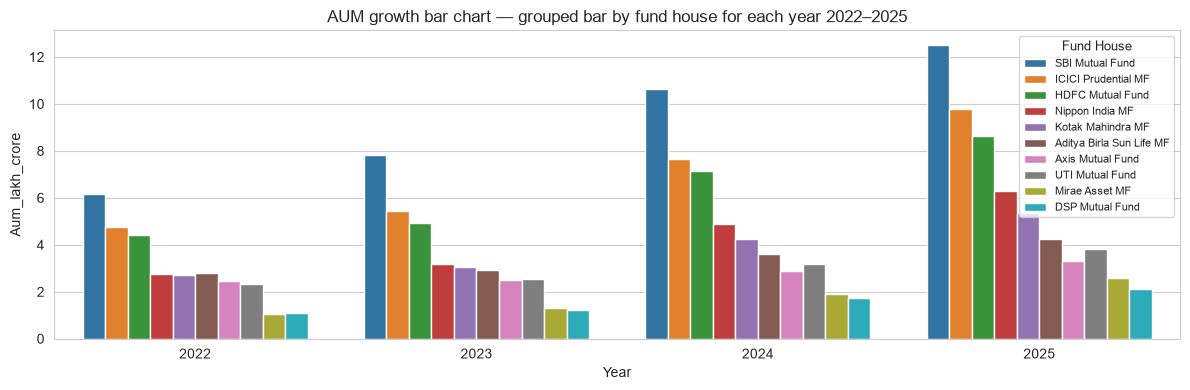

In [40]:
plt.figure(figsize=(12,4))
sns.set_style('whitegrid')

fig=sns.barplot(x=aum_by_fund_house['date'].dt.year,y='aum_lakh_crore',hue='fund_house',
                data=aum_by_fund_house,errorbar=None)
plt.title('AUM growth bar chart — grouped bar by fund house for each year 2022–2025')
plt.xlabel('Year')
plt.ylabel('Aum_lakh_crore')
plt.legend(title='Fund House', fontsize=8, title_fontsize=9)
plt.tight_layout()

plt.show()

##### Finding: SBI Mutual Fund leads AUM every year 2022–2025 and reaches ~₹12.5L Cr by 2025, roughly 1.3x ICICI Prudential (the next-largest fund house), confirming its market dominance.

##### Supporting chart: Task #2 — AUM Growth Bar Chart

### SIP inflow time-series 

In [15]:
monthly_sip_inflows=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\monthly_sip_inflows_cleaned.csv")

In [16]:
monthly_sip_inflows['month']=pd.to_datetime(monthly_sip_inflows['month'])

In [17]:
monthly_sip_inflows.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


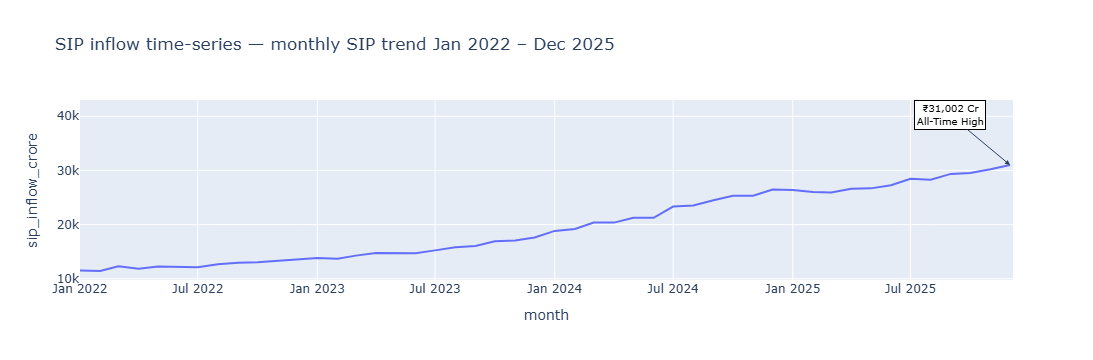

In [39]:
fig=px.line(
    monthly_sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='SIP inflow time-series — monthly SIP trend Jan 2022 – Dec 2025')

fig.add_annotation(
    x='2025-12-01',      
    y=31002,
    text='₹31,002 Cr<br>All-Time High',
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50,
    bgcolor='white',
    bordercolor='black',
    font=dict(size=10, color='black')
)

fig.show()

##### Finding: Monthly SIP inflows grew steadily from ~₹11,000 Cr (Jan 2022) to an all-time high of ₹31,002 Cr (Dec 2025), nearly tripling over the 4-year period with no major reversals.

##### Supporting chart: Task #3 — SIP Inflow Time-Series

### Category inflow heatmap

In [19]:
category_inflows=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\category_inflows_cleaned.csv")

In [20]:
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


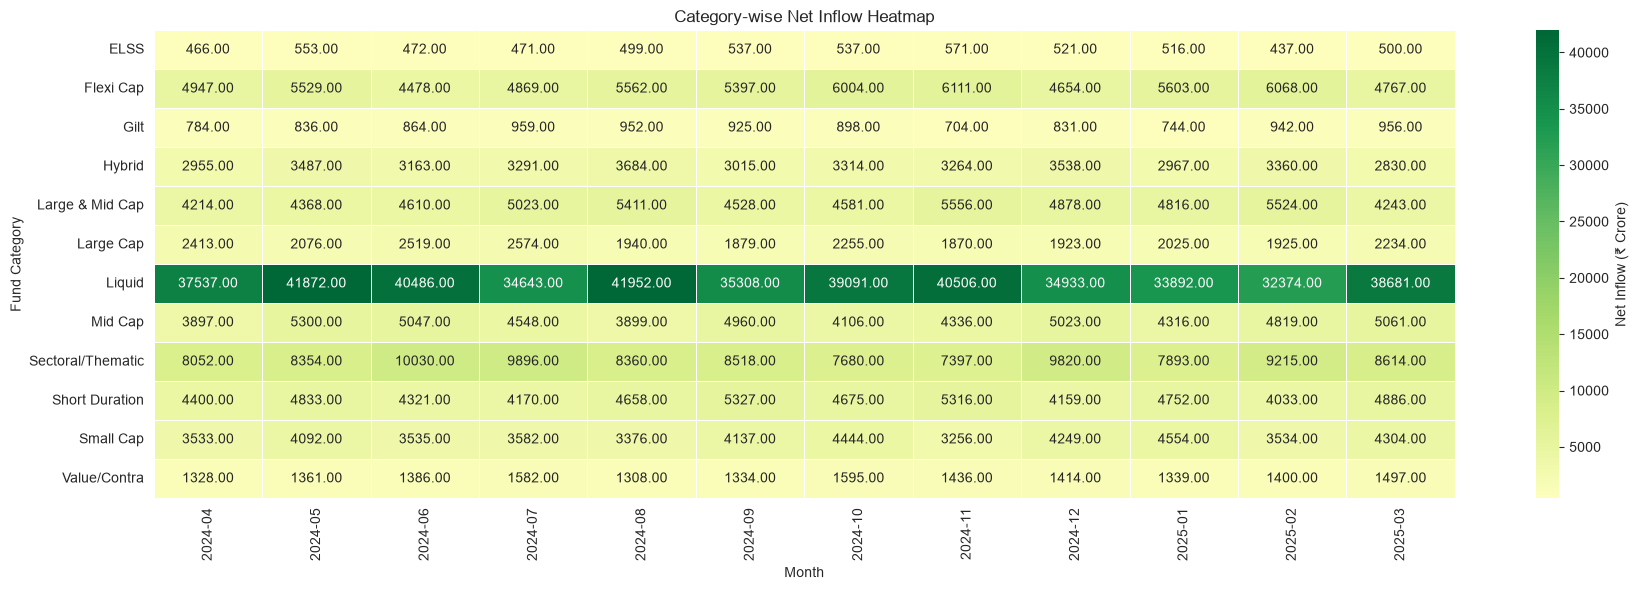

In [41]:
pivot_data = category_inflows.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

# Sort columns chronologically (pivot can scramble string-sorted months otherwise)
pivot_data = pivot_data[sorted(pivot_data.columns)]

plt.figure(figsize=(18, 6))
sns.heatmap(
    pivot_data,
    cmap='RdYlGn',       # diverging: red = low/negative inflow, green = high inflow
    center=0,             # anchors the color scale at 0, so outflows show clearly red
    annot=True,
    fmt=".2f",             
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)
plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

##### Finding: Liquid funds dominate net inflows every month (~₹33,000–42,000 Cr), 4-8x larger than any other category, while Value/Contra and ELSS consistently receive the smallest inflows across the Apr 2024 – Mar 2025 window.

##### Supporting chart: Task #4 — Category Inflow Heatmap

### Investor demographics 

In [23]:
investor_txn=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\investor_transactions_cleaned.csv")
investor_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


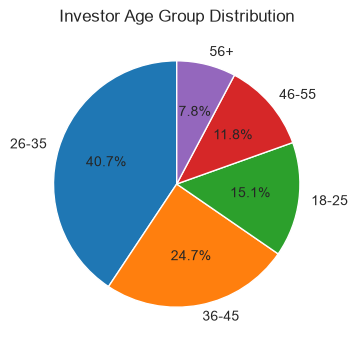

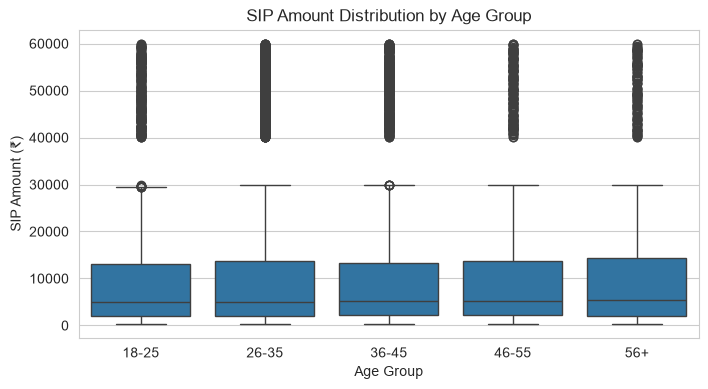

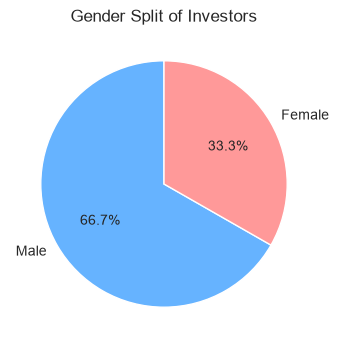

In [42]:

# --- 1. Age group distribution pie chart ---
# Use unique investors, not transaction rows, to avoid double-counting frequent SIP investors
age_dist = investor_txn.drop_duplicates('investor_id')['age_group'].value_counts()

plt.figure(figsize=(4,4))
plt.pie(age_dist, labels=age_dist.index, autopct='%1.1f%%', startangle=90)
plt.title('Investor Age Group Distribution')
plt.show()

# --- 2. SIP amount box plot by age group ---
sip_only = investor_txn[investor_txn['transaction_type'] == 'SIP']

plt.figure(figsize=(8,4))
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', order=sorted(sip_only['age_group'].unique()))
plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')
plt.show()

# --- 3. Gender split ---
gender_dist = investor_txn.drop_duplicates('investor_id')['gender'].value_counts()

plt.figure(figsize=(4,4))
plt.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Gender Split of Investors')
plt.show()

##### Finding: Investors aged 26-35 dominate (40.7%), and while SIP amounts are similar in median across all age groups (~₹5,000-7,000), a large cluster of high-value outliers (₹40,000-60,000) appears uniformly across every age group; the investor base is also skewed male (66.7% vs 33.3% female).

##### Supporting chart: Task #5 — Investor Demographics (Age Distribution, SIP Box Plot, Gender Split)

### Geographic distribution

In [25]:
# SIP amount of states (filtering SIP)
sip_state=investor_txn[investor_txn['transaction_type']=='SIP']
sip_state.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


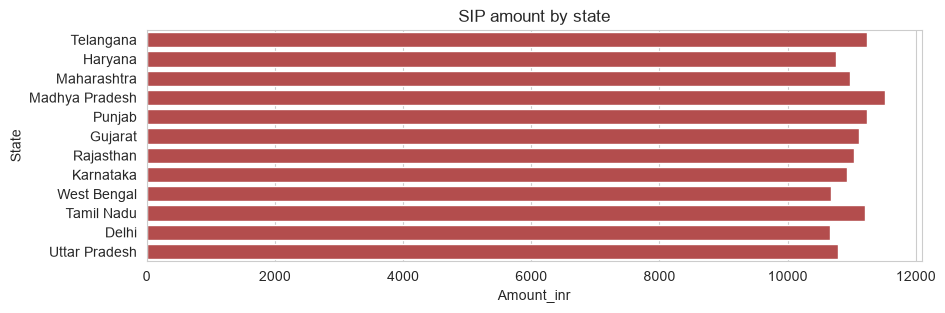

In [44]:
# Horizontal bar chart of SIP amount by state
plt.figure(figsize=(10,3))
sns.barplot(x='amount_inr',y='state',data=sip_state,errorbar=None,color='Red',saturation=.4)
plt.title('SIP amount by state')
plt.xlabel('Amount_inr')
plt.ylabel('State')
plt.show()

##### Finding: SIP amounts are remarkably uniform across all 12 states (~₹10,700–11,500), with Madhya Pradesh marginally highest and West Bengal/Delhi marginally lowest — no state shows dramatically higher SIP participation than others.

##### Supporting chart: Task #6 — Geographic Distribution (SIP by State)

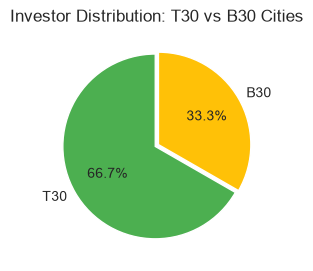

In [45]:
# T30 vs B30 city tier pie chart

# Unique investors per city tier (not transaction rows, same double-counting logic as before)
tier_dist = investor_txn.drop_duplicates('investor_id')['city_tier'].value_counts()

plt.figure(figsize=(3,3))
plt.pie(
    tier_dist, 
    labels=tier_dist.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#4CAF50', '#FFC107'],
    explode=[0.02] * len(tier_dist)  # slight separation between slices for clarity
)
plt.title('Investor Distribution: T30 vs B30 Cities')
plt.show()

##### Finding: T30 (major metro) cities account for 66.7% of investors versus 33.3% for B30, indicating mutual fund penetration is still heavily metro-concentrated despite SEBI's push for smaller-city participation.

##### Supporting chart: Task #6 — T30 vs B30 City Tier Distribution

### Folio count growth 

In [28]:
industry_folio_count=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\industry_folio_counts_cleaned.csv")
industry_folio_count.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


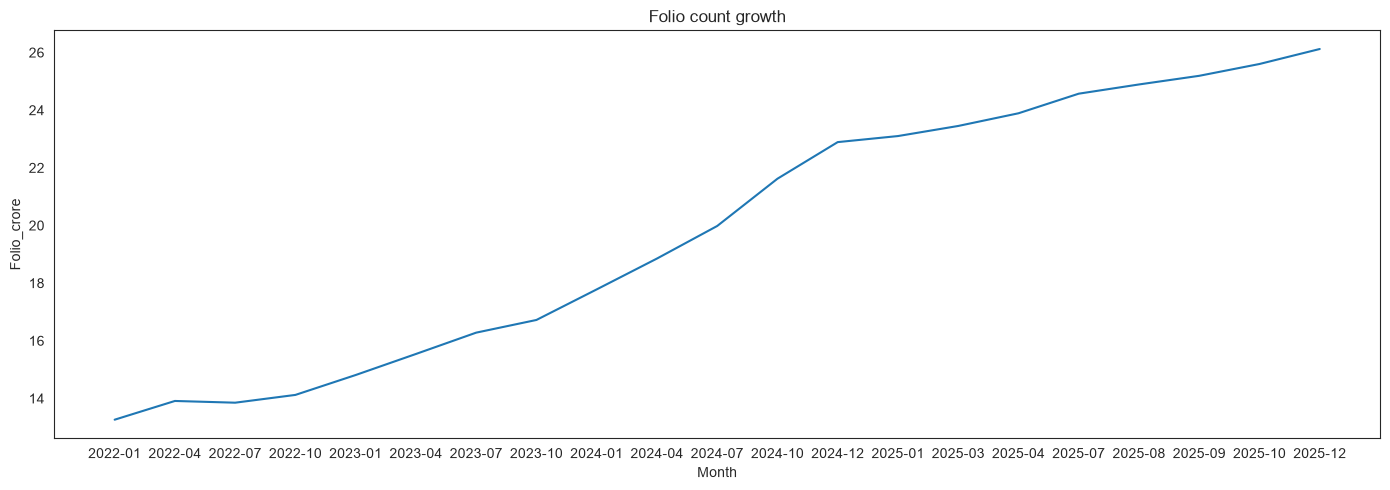

In [46]:
plt.figure(figsize=(14,5))
sns.set_style('white')
sns.lineplot(x='month',y='total_folios_crore',data=industry_folio_count)
plt.title('Folio count growth')
plt.xlabel('Month')
plt.ylabel('Folio_crore')
plt.tight_layout()
plt.show()

##### Finding: Industry folio count nearly doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), with growth accelerating sharply between mid-2024 and early-2025 (visibly steeper slope) compared to the more gradual pace in 2022-2023.

##### Supporting chart: Task #7 — Folio Count Growth

### Sector allocation donut

In [30]:
portfolio_holdings=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\portfolio_holding_cleaned.csv")
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [31]:
sector_weight=portfolio_holdings.groupby('sector')['weight_pct'].sum()
sector_weight

sector
Automobile        323.65
Banking           652.26
Cement            105.03
Consumer Goods    127.61
Diversified       169.23
Energy            117.91
FMCG              229.11
IT                455.47
Infrastructure    192.16
NBFC              119.09
Paints             89.86
Pharma            407.45
Telecom           145.62
Utilities         265.54
Name: weight_pct, dtype: float64

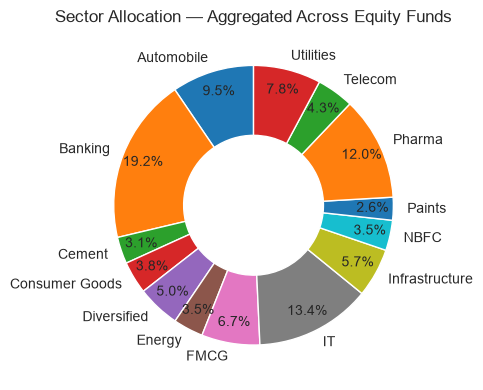

In [47]:
plt.figure(figsize=(6, 4))
plt.pie(
    sector_weight,
    labels=sector_weight.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=.5, edgecolor='white')  # width<1 creates the donut hole
)
plt.title('Sector Allocation — Aggregated Across Equity Funds')
plt.tight_layout()
plt.show()

##### Finding: Banking leads sector allocation at 19.2%, followed by IT (13.4%) and Pharma (12.0%), together making up nearly 45% of aggregated equity fund holdings — indicating notable concentration in these three sectors.

##### Supporting chart: Task #9 — Sector Allocation Donut